In [1]:
# !pip install xgboost==3.1.1 -q

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import optuna, json

from itertools import combinations
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from cuml import LogisticRegression
from cuml.preprocessing.TargetEncoder import TargetEncoder


import warnings
warnings.filterwarnings('ignore')

# Load data

In [3]:
train = pd.read_csv('/kaggle/input/playground-series-s5e11/train.csv')
test = pd.read_csv('/kaggle/input/playground-series-s5e11/test.csv')
orig = pd.read_csv('/kaggle/input/loan-prediction-dataset-2025/loan_dataset_20000.csv')
submission = pd.read_csv('/kaggle/input/playground-series-s5e11/sample_submission.csv')

In [4]:
# downcast numerical columns

def downcasting(data: pd.DataFrame, verbose: bool=True) -> pd.DataFrame:

    mem_before = data.memory_usage().sum() / 1024**2
    if verbose:
        print(f"Memory usage of dataframe is {mem_before:.2f} MB")
            
    for col in data.select_dtypes(include=["number"]).columns:
        if pd.api.types.is_integer_dtype(data[col]):
            data[col] = pd.to_numeric(data[col], downcast="integer")
        
        elif pd.api.types.is_float_dtype(data[col]):
            data[col] = pd.to_numeric(data[col], downcast="float")

    mem_after = data.memory_usage().sum() / 1024**2
    if verbose:
        print(f"Memory usage after optimization is: {mem_after:.2f} MB")
        print(f"Decreased by {(100 * (mem_before - mem_after) / mem_before):.1f}%\n")

    
    return data

train = downcasting(train)
test = downcasting(test)
orig = downcasting(orig)

Memory usage of dataframe is 58.91 MB
Memory usage after optimization is: 46.45 MB
Decreased by 21.2%

Memory usage of dataframe is 23.31 MB
Memory usage after optimization is: 18.94 MB
Decreased by 18.7%

Memory usage of dataframe is 3.36 MB
Memory usage after optimization is: 2.08 MB
Decreased by 38.1%



In [5]:
train.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [6]:
orig.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.880005,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.169983,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.320000,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.070007,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.500000,D5,1,17467.56,3593.91,2,0,2,1


# Data Analaysis

In [7]:
target = 'loan_paid_back'
cats = ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']

# collect only common columns
common_columns = [col for col in train.columns if col not in ['id', target]]

In [8]:
# function to compare train and test dataframes
def compare_dataframes(train_df, test_df, cols):
    report_data = []
    
    all_cols = cols

    for col in all_cols:
        row_data = {'Column': col}
        
        if col in train_df.columns and col in test_df.columns:
            if pd.api.types.is_numeric_dtype(train_df[col]):
                train_stats = train_df[col].describe()
                test_stats = test_df[col].describe()
                
                row_data.update({
                    'Data Type': 'Numeric',
                    'Train Mean': train_stats['mean'],
                    'Test Mean': test_stats['mean'],
                    'Train Median': train_stats['50%'],
                    'Test Median': test_stats['50%'],
                    'Train Std': train_stats['std'],
                    'Test Std': test_stats['std']
                })
            else:
                train_counts = train_df[col].value_counts(normalize=True)
                test_counts = test_df[col].value_counts(normalize=True)
                
                row_data.update({
                    'Data Type': 'Categorical',
                    'Train Unique': len(train_df[col].unique()),
                    'Test Unique': len(test_df[col].unique()),
                    'Train Mode': train_df[col].mode()[0],
                    'Test Mode': test_df[col].mode()[0]
                })

            if 'Train Mean' in row_data:
                mean_diff_pct = (abs(row_data['Train Mean'] - row_data['Test Mean']) / 
                                 np.mean([row_data['Train Mean'], row_data['Test Mean']])) * 100
                row_data['Mean Diff %'] = f"{mean_diff_pct:.2f}%"
            
            row_data['Train Count'] = train_df[col].count()
            row_data['Test Count'] = test_df[col].count()
        
        report_data.append(row_data)

    report_df = pd.DataFrame(report_data).apply(lambda x: round(x, 2), axis = 0)
    return report_df.set_index('Column')

In [9]:
report = compare_dataframes(train, test, common_columns)
report

,Data Type,Train Mean,Test Mean,Train Median,Test Median,Train Std,Test Std,Mean Diff %,Train Count,Test Count,Train Unique,Test Unique,Train Mode,Test Mode
Column,,,,,,,,,,,,,,
annual_income,Numeric,48212.20,48233.08,46557.68,46528.98,26711.94,26719.66,0.04%,593994,254569,NaN,NaN,NaN,NaN
debt_to_income_ratio,Numeric,0.12,0.12,0.10,0.10,0.07,0.07,0.09%,593994,254569,NaN,NaN,NaN,NaN
credit_score,Numeric,680.92,681.04,682.00,683.00,55.42,55.62,0.02%,593994,254569,NaN,NaN,NaN,NaN
loan_amount,Numeric,15020.30,15016.75,15000.22,15000.22,6926.53,6922.17,0.02%,593994,254569,NaN,NaN,NaN,NaN
interest_rate,Numeric,12.36,12.35,12.37,12.37,2.01,2.02,0.03%,593994,254569,NaN,NaN,NaN,NaN
gender,Categorical,NaN,NaN,NaN,NaN,NaN,NaN,NaN,593994,254569,3.0,3.0,Female,Female
marital_status,Categorical,NaN,NaN,NaN,NaN,NaN,NaN,NaN,593994,254569,4.0,4.0,Single,Single
education_level,Categorical,NaN,NaN,NaN,NaN,NaN,NaN,NaN,593994,254569,5.0,5.0,Bachelor's,Bachelor's
employment_status,Categorical,NaN,NaN,NaN,NaN,NaN,NaN,NaN,593994,254569,5.0,5.0,Employed,Employed


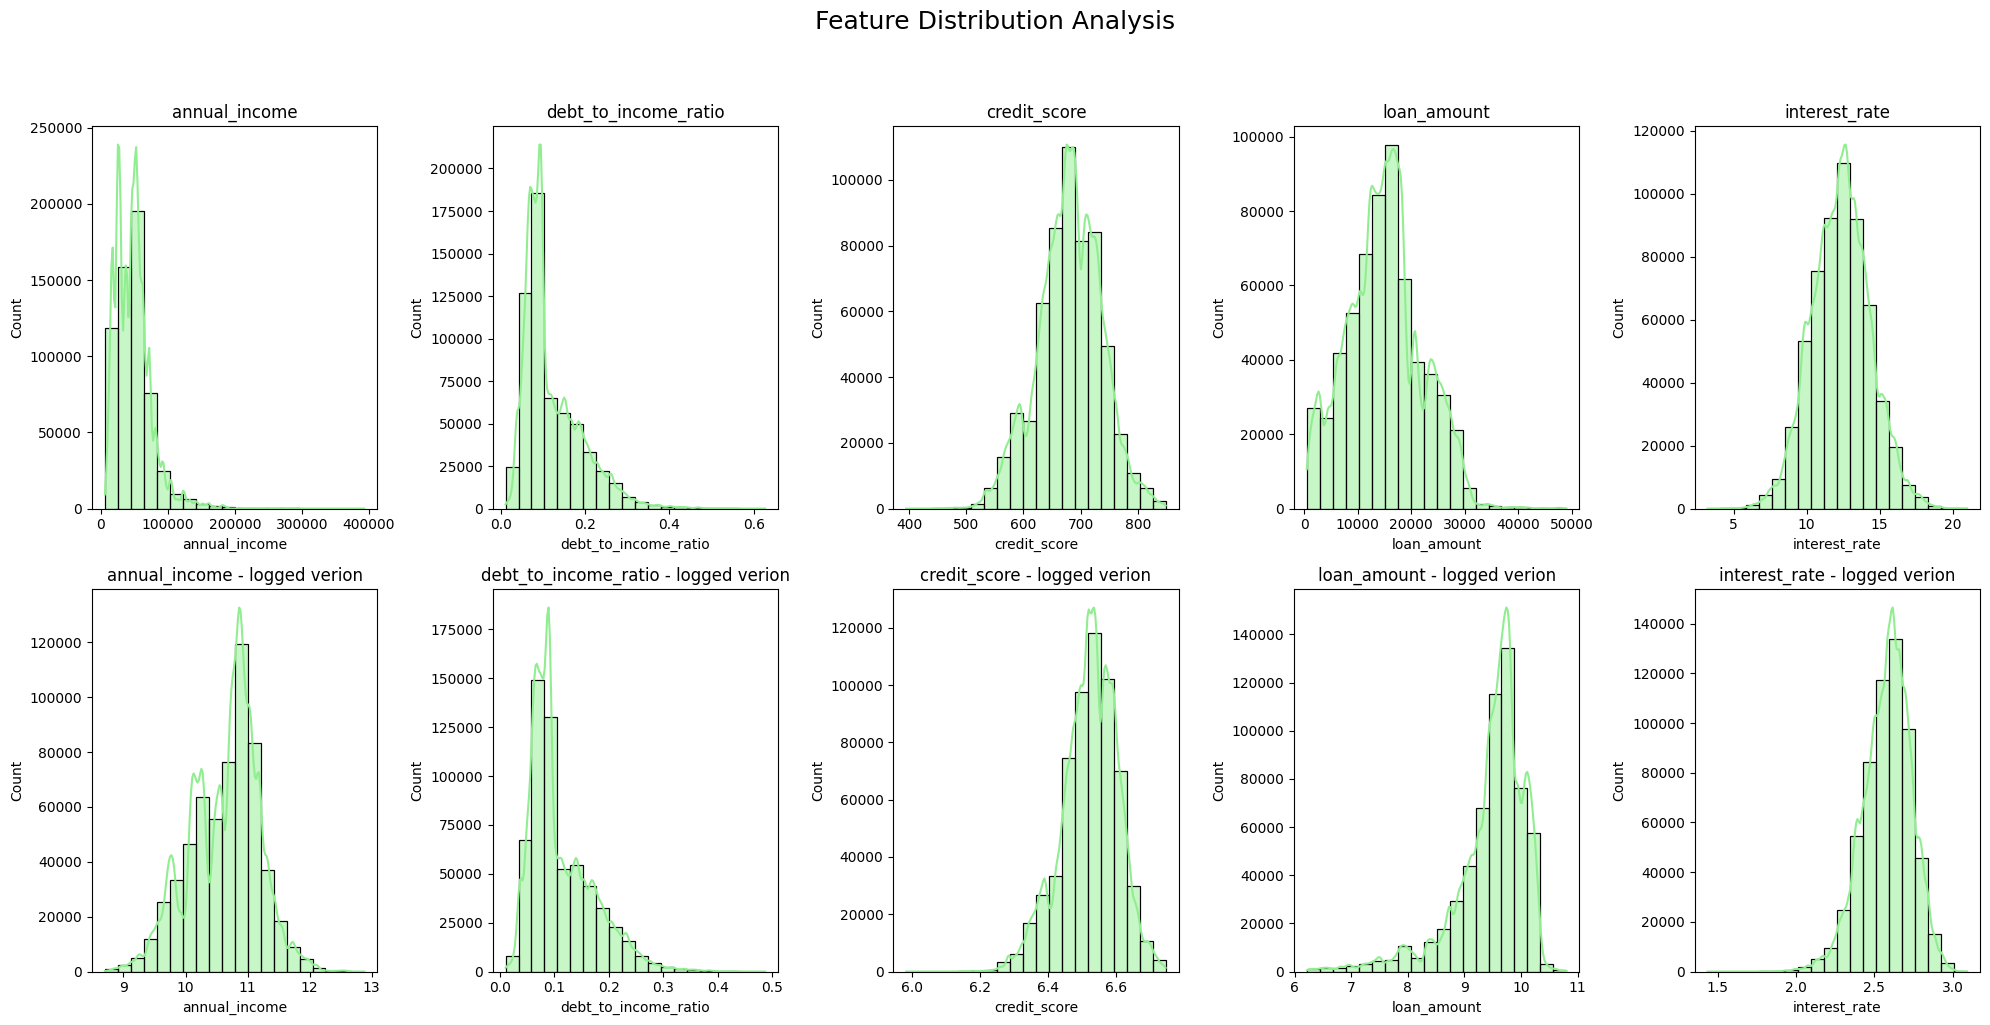

In [10]:
cols = ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']
num_features = len(cols)

fig, axs = plt.subplots(2, 5, figsize=(20, 10))

fig.suptitle('Feature Distribution Analysis', fontsize=18, y=1.02)

for i in range(num_features):
    sns.histplot(
        data=train,
        x=cols[i],
        bins=20,
        ax=axs[0, i],
        color='lightgreen',
        edgecolor='black',
        kde=True
    )
    axs[0, i].set_title(cols[i])


# try logged version of columns
train_copy = train.copy(deep=True)
for col in cols:
    train_copy[col] = np.log1p(train_copy[col])
    
for i in range(num_features):
    sns.histplot(
        data=train_copy,
        x=cols[i],
        bins=20,
        ax=axs[1, i],
        color='lightgreen',
        edgecolor='black',
        kde=True
    )
    axs[1, i].set_title(f"{cols[i]} - logged verion")



plt.tight_layout(rect=[0, 0, 1, 0.98]) 
plt.show()

In [11]:
print("<------ Train ------>\n")
for col in cols:
    print(f"{col}: {train[col].nunique()} unique values")

print('\n<------ Test ------>\n')
for col in cols:
    print(f"{col}: {test[col].nunique()} unique values")
    

<------ Train ------>

annual_income: 119728 unique values
debt_to_income_ratio: 526 unique values
credit_score: 399 unique values
loan_amount: 111570 unique values
interest_rate: 1454 unique values

<------ Test ------>

annual_income: 67287 unique values
debt_to_income_ratio: 506 unique values
credit_score: 389 unique values
loan_amount: 65199 unique values
interest_rate: 1385 unique values


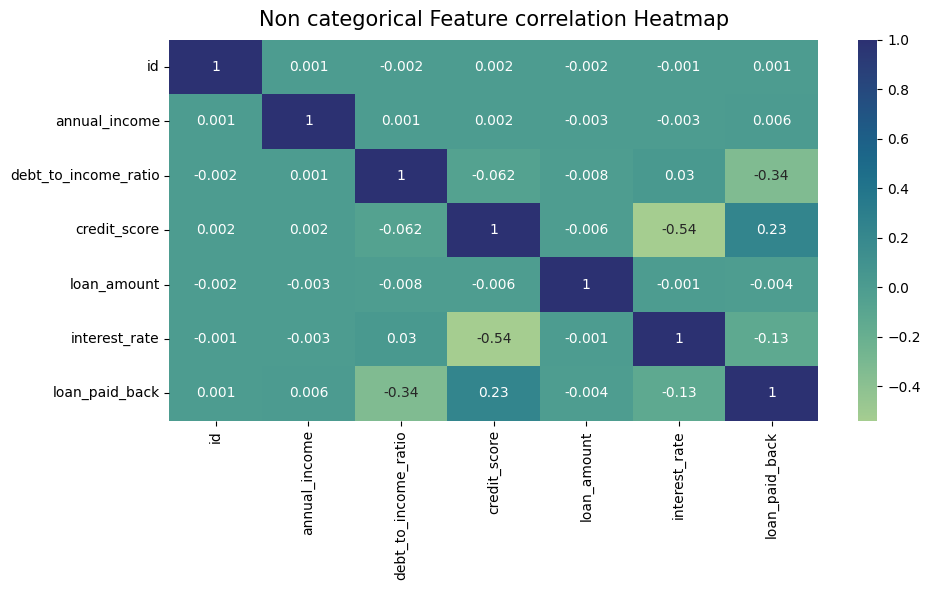

In [12]:
fig, ax = plt.subplots(figsize=(10,6))

corr = train.corr(numeric_only= True).round(3)

sns.heatmap(corr, cmap = 'crest', annot = True)
plt.title('Non categorical Feature correlation Heatmap', fontsize = 15, pad=10)
plt.tight_layout()
plt.show()



# Feature Engineering

The below feature engineering is used from the Chris Deotte notebook: [https://www.kaggle.com/code/cdeotte/xgboost-using-original-data-cv-0-976](https://www.kaggle.com/code/cdeotte/xgboost-using-original-data-cv-0-976)

In [13]:
test['loan_paid_back'] = -1

combine_cols = train.columns.to_list()[1:]
combine = pd.concat([train[combine_cols], test[combine_cols], orig[combine_cols]],axis=0)


CATS = []
NUMS = []
for c in combine.columns[:-1]:
    t = "CAT"
    if combine[c].dtype=='object':
        CATS.append(c)
    else:
        NUMS.append(c)
        t = "NUM"
    n = combine[c].nunique()
    na = combine[c].isna().sum()
    print(f"[{t}] {c} has {n} unique and {na} NA")
print("CATS:", CATS )
print("NUMS:", NUMS )



[NUM] annual_income has 152960 unique and 0 NA
[NUM] debt_to_income_ratio has 572 unique and 0 NA
[NUM] credit_score has 406 unique and 0 NA
[NUM] loan_amount has 139138 unique and 0 NA
[NUM] interest_rate has 1498 unique and 0 NA
[CAT] gender has 3 unique and 0 NA
[CAT] marital_status has 4 unique and 0 NA
[CAT] education_level has 5 unique and 0 NA
[CAT] employment_status has 5 unique and 0 NA
[CAT] loan_purpose has 8 unique and 0 NA
[CAT] grade_subgrade has 30 unique and 0 NA
CATS: ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']
NUMS: ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']


# Feature Engineer (LE - Label Encode)

We will label encode all categorical columns. Also we will make a duplicate of each numerical column and treat the copy as a categorical column.


In [14]:
CATS1 = []
SIZES = {}
for c in NUMS + CATS:
    n = c
    if c in NUMS: 
        n = f"{c}2"
        CATS1.append(n)
    combine[n],_ = combine[c].factorize()
    SIZES[n] = combine[n].max()+1

    combine[c] = combine[c].astype('int32')
    combine[n] = combine[n].astype('int32')

print("New CATS:", CATS1 )
print("Cardinality of all CATS:", SIZES )

New CATS: ['annual_income2', 'debt_to_income_ratio2', 'credit_score2', 'loan_amount2', 'interest_rate2']
Cardinality of all CATS: {'annual_income2': 152960, 'debt_to_income_ratio2': 572, 'credit_score2': 406, 'loan_amount2': 139138, 'interest_rate2': 1498, 'gender': 3, 'marital_status': 4, 'education_level': 5, 'employment_status': 5, 'loan_purpose': 8, 'grade_subgrade': 30}


# Feature Engineer (Combine Column Pairs)

We will create a new categorical column from every pair of existing categorical columns. The original categorical columns have been label encoded into integers from 0 to N-1 each. Therefore we can create a new column with unique integers using the formula new_cols[name] = combine[c1] * SIZES[c2] + combine[c2].


In [15]:
pairs = combinations(CATS + CATS1, 2)
new_cols = {}
CATS2 = []

for c1, c2 in pairs:
    name = "_".join(sorted((c1, c2)))
    new_cols[name] = combine[c1] * SIZES[c2] + combine[c2]
    CATS2.append(name)
if new_cols:
    new_df = pd.DataFrame(new_cols)         
    combine = pd.concat([combine, new_df], axis=1) 

print(f"Created {len(CATS2)} new CAT columns")

Created 55 new CAT columns


# Feature Engineer (CE - Count Encoding)
We now have 55 categorical columns. We will count encode each of them and create 55 new columns.

In [16]:
# Count Encoding

CE = []
CC = CATS+CATS1+CATS2

print(f"Processing {len(CC)} columns... ",end="")
for i,c in enumerate(CC):
    if i%10==0: print(f"{i}, ",end="")
    tmp = combine.groupby(c).loan_paid_back.count()
    tmp = tmp.astype('int32')
    tmp.name = f"CE_{c}"
    CE.append( f"CE_{c}" )
    combine = combine.merge(tmp, on=c, how='left')
print()

Processing 66 columns... 0, 10, 20, 30, 40, 50, 60, 


In [17]:
train = combine.iloc[:len(train)]
test = combine.iloc[len(train):len(train)+len(test)]
orig = combine.iloc[-len(orig):]
del combine
print("Train shape", train.shape,"Test shape", test.shape,"Original shape", orig.shape )

Train shape (593994, 138) Test shape (254569, 138) Original shape (20000, 138)


In [18]:
FEATURES = NUMS+CATS+CATS1+CATS2+CE
print(f"We have {len(FEATURES)} features.")


We have 137 features.


## Data Loader for QuantileDMatrix
We need the following data loader to use XGB's memory efficient `QuantileDMatrix`. This data loader yields batches of data on GPU for XGB.

In [19]:
import xgboost as xgb
class IterLoadForDMatrix(xgb.core.DataIter):
    def __init__(self, df=None, features=None, target=None, batch_size=256*1024):
        self.features = features
        self.target = target
        self.df = df
        self.it = 0 
        self.batch_size = batch_size
        self.batches = int( np.ceil( len(df) / self.batch_size ) )
        super().__init__()

    def reset(self):
        '''Reset the iterator'''
        self.it = 0

    def next(self, input_data):
        '''Yield next batch of data.'''
        if self.it == self.batches:
            return 0 # Return 0 when there's no more batch.
        
        a = self.it * self.batch_size
        b = min( (self.it + 1) * self.batch_size, len(self.df) )
        #dt = cudf.DataFrame(self.df.iloc[a:b])
        dt = self.df.iloc[a:b]
        input_data(data=dt[self.features], label=dt[self.target]) 
        self.it += 1
        return 1

# Train XGB w/ Original Data as Rows
We will now train XGBoost with adding original data as new rows. Inside each KFold for loop iteration, we will concatenate the original data to the train data as new rows. 

We will also use a `QuantileDMatrix` instead of a `DMatrix`. This reduces memory usage because the data will be loaded into GPU VRAM in batches and compressed in batches. This is different than the basic `DMatrix` which tries to load all the train data into GPU VRAM at the same time which spikes the memory and can cause OOM.

In [20]:
FEATURES = NUMS+CATS+CATS1+CATS2+CE
print(f"We have {len(FEATURES)} features.")

FOLDS = 7
SEED = 42

params = {
    "objective": "binary:logistic",  
    "eval_metric": "auc",           
    "learning_rate": 0.01,
    "max_depth": 0,
    "subsample": 0.8,
    "colsample_bytree": 0.7,
    "seed": SEED,
    "device": "cuda",
    "grow_policy": "lossguide", 
    "max_leaves": 32,          

    'scale_pos_weight': 0.8, # usefull for unbalanced data
    "min_samples_split": 5,
    'lambda': 5.0, 
    'alpha': 2.5,
}

We have 137 features.


In [21]:
oof_preds = np.zeros(len(train))
test_preds = np.zeros(len(test))

kf = KFold(n_splits=FOLDS, shuffle=True, random_state=SEED)

for fold, (train_idx, val_idx) in enumerate(kf.split(train)):
    print("#"*25)
    print(f"### Fold {fold+1} ###")
    print("#"*25)

    Xy_train = train.iloc[train_idx][ FEATURES+['loan_paid_back'] ].copy()
    Xy_more = orig[ FEATURES+['loan_paid_back'] ]
    for k in range(1):
        Xy_train = pd.concat([Xy_train,Xy_more],axis=0,ignore_index=True)
    
    X_valid = train.iloc[val_idx][FEATURES].copy()
    y_valid = train.iloc[val_idx]['loan_paid_back']
    X_test = test[FEATURES].copy()

    CC = CATS1+CATS2
    print(f"Target encoding {len(CC)} features... ",end="")
    for i,c in enumerate(CC):
        if i%10==0: print(f"{i}, ",end="")
        TE0 = TargetEncoder(n_folds=10, smooth=0, split_method='random', stat='mean')
        Xy_train[c] = TE0.fit_transform(Xy_train[c],Xy_train['loan_paid_back']).astype('float32')
        X_valid[c] = TE0.transform(X_valid[c]).astype('float32')
        X_test[c] = TE0.transform(X_test[c]).astype('float32')
    print()

    Xy_train[CATS] = Xy_train[CATS].astype('category')
    X_valid[CATS] = X_valid[CATS].astype('category')
    X_test[CATS] = X_test[CATS].astype('category')

    Xy_train = IterLoadForDMatrix(Xy_train, FEATURES, 'loan_paid_back')
    dtrain = xgb.QuantileDMatrix(Xy_train, enable_categorical=True, max_bin=256)
    dval   = xgb.DMatrix(X_valid, label=y_valid, enable_categorical=True)
    dtest  = xgb.DMatrix(X_test, enable_categorical=True)

    model = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=10_000,
        evals=[(dtrain, "train"), (dval, "valid")],
        early_stopping_rounds=300,
        verbose_eval=300
    )

    oof_preds[val_idx] = model.predict(dval, iteration_range=(0, model.best_iteration + 1))
    test_preds += model.predict(dtest, iteration_range=(0, model.best_iteration + 1)) / FOLDS

#########################
### Fold 1 ###
#########################
Target encoding 60 features... 0, 10, 20, 30, 40, 50, 
[0]	train-auc:0.91067	valid-auc:0.91375
[300]	train-auc:0.92411	valid-auc:0.92552
[600]	train-auc:0.92661	valid-auc:0.92670
[900]	train-auc:0.92839	valid-auc:0.92698
[1200]	train-auc:0.92991	valid-auc:0.92703
[1500]	train-auc:0.93128	valid-auc:0.92704
[1669]	train-auc:0.93203	valid-auc:0.92703
#########################
### Fold 2 ###
#########################
Target encoding 60 features... 0, 10, 20, 30, 40, 50, 
[0]	train-auc:0.91193	valid-auc:0.91394
[300]	train-auc:0.92430	valid-auc:0.92458
[600]	train-auc:0.92681	valid-auc:0.92584
[900]	train-auc:0.92858	valid-auc:0.92622
[1200]	train-auc:0.93005	valid-auc:0.92632
[1500]	train-auc:0.93141	valid-auc:0.92635
[1800]	train-auc:0.93273	valid-auc:0.92634
[1872]	train-auc:0.93302	valid-auc:0.92633
#########################
### Fold 3 ###
#########################
Target encoding 60 features... 0, 10, 20, 30, 40, 50, 
[

## CV Score

In [22]:
m = roc_auc_score(train.loan_paid_back, oof_preds)
print(f"XGB with Original Data as rows CV = {m}")

XGB with Original Data as rows CV = 0.9261819181597949


## Feature Importance

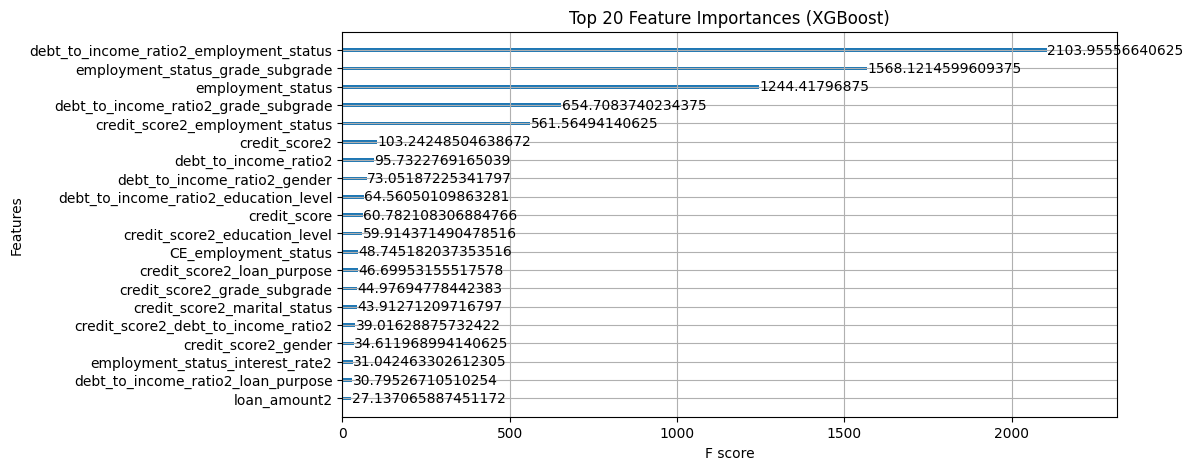

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
xgb.plot_importance(model, max_num_features=20, importance_type='gain',ax=ax)
plt.title("Top 20 Feature Importances (XGBoost)")
plt.show()

In [24]:
# save results
submission['loan_paid_back'] = test_preds
submission.to_csv('submission_orig_as_rows.csv', index=False) 
submission.head()

,id,loan_paid_back
0,593994,0.936951
1,593995,0.961459
2,593996,0.440152
3,593997,0.874853
4,593998,0.952292


# Previous Version of Notebook

In [25]:
train = pd.read_csv('/kaggle/input/playground-series-s5e11/train.csv')
test = pd.read_csv('/kaggle/input/playground-series-s5e11/test.csv')
orig = pd.read_csv('/kaggle/input/loan-prediction-dataset-2025/loan_dataset_20000.csv')
submission = pd.read_csv('/kaggle/input/playground-series-s5e11/sample_submission.csv')


target = 'loan_paid_back'
cats = ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']

# collect only common columns
common_columns = [col for col in train.columns if col not in ['id', target]]

In [26]:
# log of numeric features
cols = ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']
cols_logged = []

for col in cols:
    for df in [train, test, orig]:
        df[f"{col}_logged"] = np.log1p(df[col])
    
    cols_logged.append(f"{col}_logged")


some feature engineering creative techniques from [https://www.kaggle.com/code/analyticaobscura/s5e11-loan-payback-xgb-lgbm-ann](https://www.kaggle.com/code/analyticaobscura/s5e11-loan-payback-xgb-lgbm-ann)

In [27]:
def credit_features(train, test):

    first_cols = set(train.columns.to_list())
    
    train['loan_to_income'] = train['loan_amount'] / (train['annual_income'] + 1)
    test['loan_to_income'] = test['loan_amount'] / (test['annual_income'] + 1)
    
    train['total_debt'] = train['debt_to_income_ratio'] * train['annual_income']
    test['total_debt'] = test['debt_to_income_ratio'] * test['annual_income']
    
    train['available_income'] = train['annual_income'] * (1 - train['debt_to_income_ratio'])
    test['available_income'] = test['annual_income'] * (1 - test['debt_to_income_ratio'])
    
    train['affordability'] = train['available_income'] / (train['loan_amount'] + 1)
    test['affordability'] = test['available_income'] / (test['loan_amount'] + 1)
    
    train['monthly_payment'] = train['loan_amount'] * (1 + train['interest_rate']/100) / 12
    test['monthly_payment'] = test['loan_amount'] * (1 + test['interest_rate']/100) / 12
    
    train['payment_to_income'] = train['monthly_payment'] / (train['annual_income']/12 + 1)
    test['payment_to_income'] = test['monthly_payment'] / (test['annual_income']/12 + 1)
    
    train['risk_score'] = (train['debt_to_income_ratio'] * 40 + 
                           (1 - train['credit_score']/850) * 30 + train['interest_rate'] * 2)
    test['risk_score'] = (test['debt_to_income_ratio'] * 40 + 
                          (1 - test['credit_score']/850) * 30 + test['interest_rate'] * 2)
    
    train['grade_number'] = train['grade_subgrade'].str[1].astype(int)
    test['grade_number'] = test['grade_subgrade'].str[1].astype(int)

    train['grade'] = train['grade_subgrade'].str[0]
    test['grade'] = test['grade_subgrade'].str[0]
    
    grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
    train['grade_rank'] = train['grade'].map(grade_map)
    test['grade_rank'] = test['grade'].map(grade_map)
    
    train['grade_combined'] = train['grade_rank'] * 10 + train['grade_number']
    test['grade_combined'] = test['grade_rank'] * 10 + test['grade_number']
    
    train['credit_interest'] = train['credit_score'] * train['interest_rate'] / 100
    test['credit_interest'] = test['credit_score'] * test['interest_rate'] / 100
    
    train['income_credit'] = np.log1p(train['annual_income']) * train['credit_score'] / 1000
    test['income_credit'] = np.log1p(test['annual_income']) * test['credit_score'] / 1000
    
    train['debt_loan'] = train['debt_to_income_ratio'] * np.log1p(train['loan_amount'])
    test['debt_loan'] = test['debt_to_income_ratio'] * np.log1p(test['loan_amount'])

    created_columns = list(set(train.columns.to_list()) ^ first_cols)
    
    print(f"{len(created_columns)} Features created")
    
    return train, test, created_columns

train, test, new_cols = credit_features(train, test)

cats.append('grade')

14 Features created


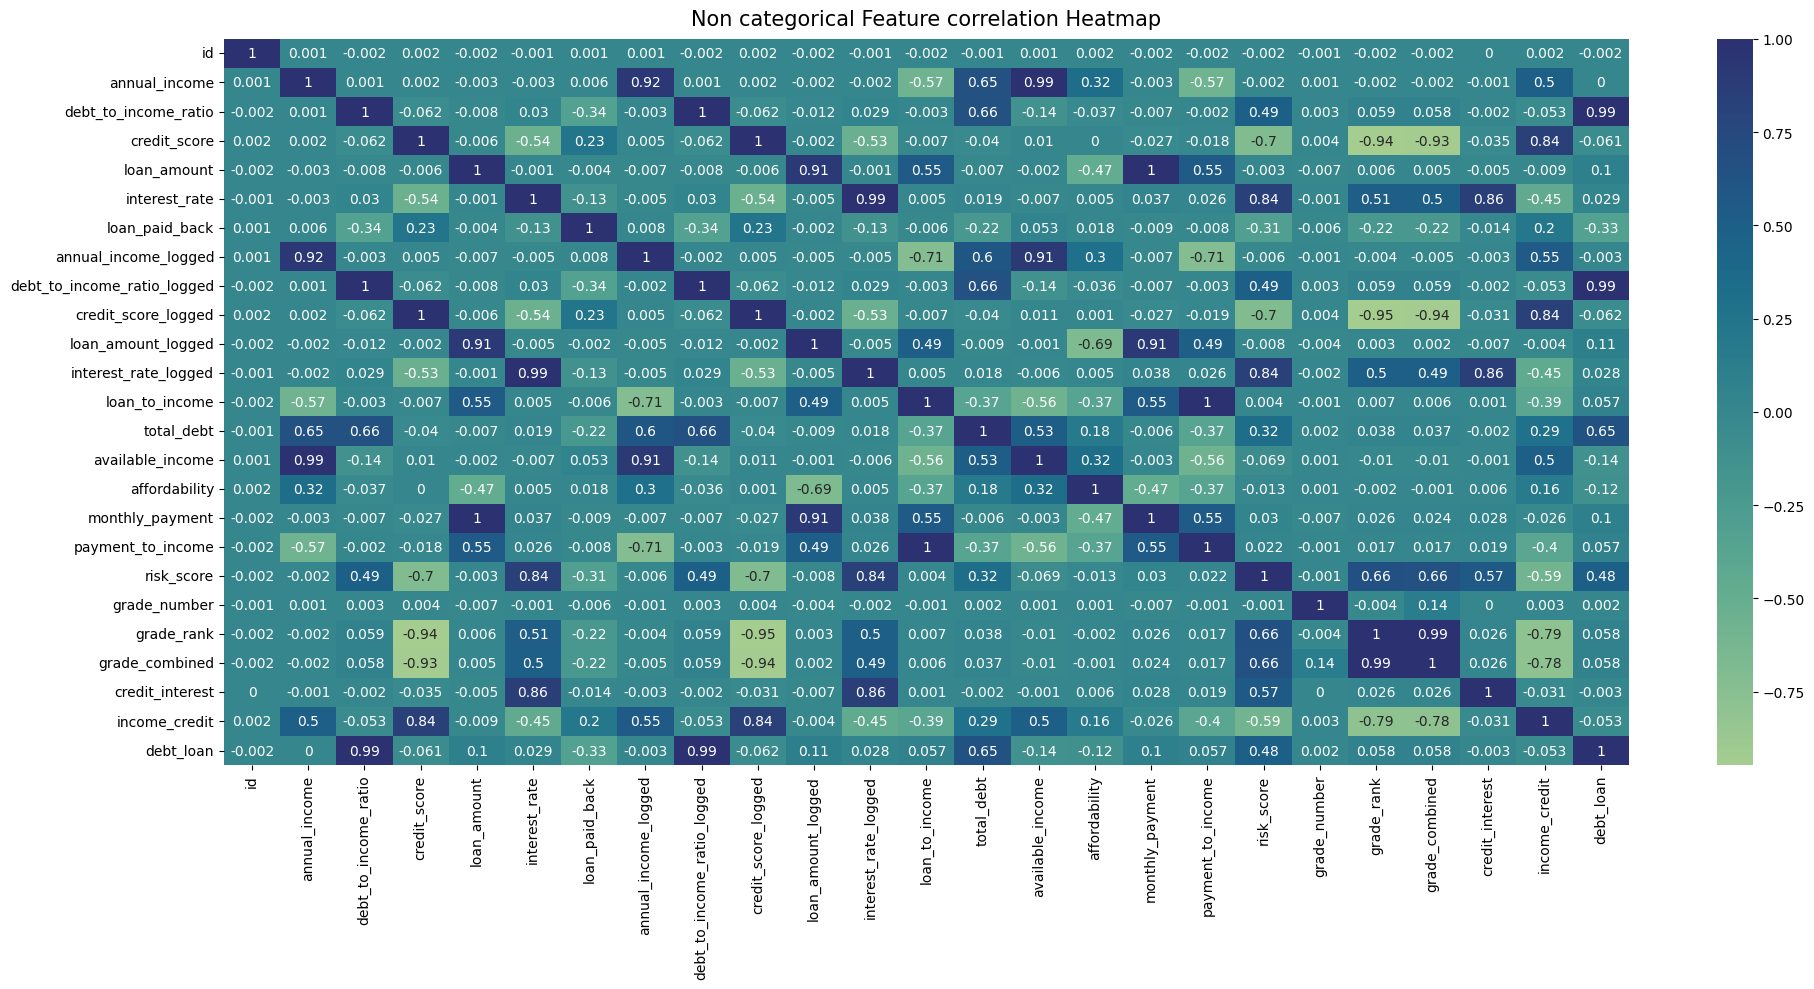

In [28]:
fig, ax = plt.subplots(figsize=(20,10))

corr = train.corr(numeric_only= True).round(3)

sns.heatmap(corr, cmap = 'crest', annot = True)
plt.title('Non categorical Feature correlation Heatmap', fontsize = 15, pad=10)
plt.tight_layout()
plt.show()



In [29]:
INTER = []

for col1, col2 in combinations(common_columns, 2):
    new_col_name = f'{col1}_{col2}'
    INTER.append(new_col_name)
    for df in [train, test, orig]:
        df[new_col_name] = df[col1].astype(str) + '_' + df[col2].astype(str)

print(f'{len(INTER)} Features.')


55 Features.


In [30]:
ORIG = []

for col in common_columns:
    # MEAN
    mean_map = orig.groupby(col)[target].mean()
    new_mean_col_name = f"orig_mean_{col}"
    mean_map.name = new_mean_col_name
    
    train = train.merge(mean_map, on=col, how='left')
    test = test.merge(mean_map, on=col, how='left')
    ORIG.append(new_mean_col_name)

    # COUNT
    new_count_col_name = f"orig_count_{col}"
    count_map = orig.groupby(col).size().reset_index(name=new_count_col_name)
    
    train = train.merge(count_map, on=col, how='left')
    test = test.merge(count_map, on=col, how='left')
    ORIG.append(new_count_col_name)

print(len(ORIG), 'Orig Features Created!!')

22 Orig Features Created!!


In [31]:
FEATURES = common_columns + ORIG + INTER + cols_logged + new_cols
print(len(FEATURES), 'Features will be used')

107 Features will be used


# Training

In [32]:
X = train[FEATURES].copy(deep = True)
y = train[target].copy(deep = True)

test = test.drop(columns=['id'], axis=1).copy(deep=True)

In [33]:
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'max_depth': 7,
    'colsample_bytree': 0.8,
    'subsample': 0.8,
    'n_estimators': 10000,
    'learning_rate': 0.01,
    'early_stopping_rounds': 300,
    'random_state': 42,
    'n_jobs': -1,
    'device': 'cuda',
    'enable_categorical': True,

    'scale_pos_weight': 0.8, # usefull for unbalanced data
    "min_samples_split": 5,
    'lambda': 5.0, 
    'alpha': 2.5,
    'max_bin': 512
}

### Cuml Target Encoding Practical Notebook: [https://github.com/rapidsai/cuml/blob/branch-0.16/notebooks/target_encoder_walkthrough.ipynb](https://github.com/rapidsai/cuml/blob/branch-0.16/notebooks/target_encoder_walkthrough.ipynb)

In [34]:
set(X.columns) ^ set(test.columns)

set()

In [35]:
N_SPLITS = 7
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)


oof_preds = np.zeros(len(X))
test_preds1 = np.zeros(len(test))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f'--- Fold {fold}/{N_SPLITS} ---')
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    X_test = test[FEATURES].copy()

    for col in INTER:
        TE = TargetEncoder(n_folds=10, smooth=0, split_method='random', stat='mean')
    
        X_train[col] = TE.fit_transform(X_train[[col]], y_train)
        X_val[col] = TE.transform(X_val[[col]])
        X_test[col] = TE.transform(X_test[[col]])

    X_train[cats] = X_train[cats].astype('category')
    X_val[cats] = X_val[cats].astype('category')
    X_test[cats] = X_test[cats].astype('category')

    model = XGBClassifier(**params)
    
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=500)

    val_preds = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_preds
    
    fold_score = roc_auc_score(y_val, val_preds)
    print(f'Fold {fold} AUC: {fold_score:.4f}')
    test_preds1 += model.predict_proba(X_test)[:, 1] / N_SPLITS

overall_auc = roc_auc_score(y, oof_preds)
print(f'====================')
print(f'Overall OOF AUC: {overall_auc:.4f}')
print(f'====================')

--- Fold 1/7 ---
[0]	validation_0-auc:0.91803
[500]	validation_0-auc:0.92644
[1000]	validation_0-auc:0.92711
[1500]	validation_0-auc:0.92717
[1802]	validation_0-auc:0.92712
Fold 1 AUC: 0.9272
--- Fold 2/7 ---
[0]	validation_0-auc:0.91827
[500]	validation_0-auc:0.92628
[1000]	validation_0-auc:0.92714
[1500]	validation_0-auc:0.92728
[1933]	validation_0-auc:0.92728
Fold 2 AUC: 0.9273
--- Fold 3/7 ---
[0]	validation_0-auc:0.91744
[500]	validation_0-auc:0.92565
[1000]	validation_0-auc:0.92633
[1500]	validation_0-auc:0.92639
[1734]	validation_0-auc:0.92639
Fold 3 AUC: 0.9264
--- Fold 4/7 ---
[0]	validation_0-auc:0.91714
[500]	validation_0-auc:0.92430
[1000]	validation_0-auc:0.92478
[1500]	validation_0-auc:0.92478
[1567]	validation_0-auc:0.92476
Fold 4 AUC: 0.9248
--- Fold 5/7 ---
[0]	validation_0-auc:0.91628
[500]	validation_0-auc:0.92430
[1000]	validation_0-auc:0.92498
[1500]	validation_0-auc:0.92500
[1984]	validation_0-auc:0.92496
Fold 5 AUC: 0.9250
--- Fold 6/7 ---
[0]	validation_0-auc:0.

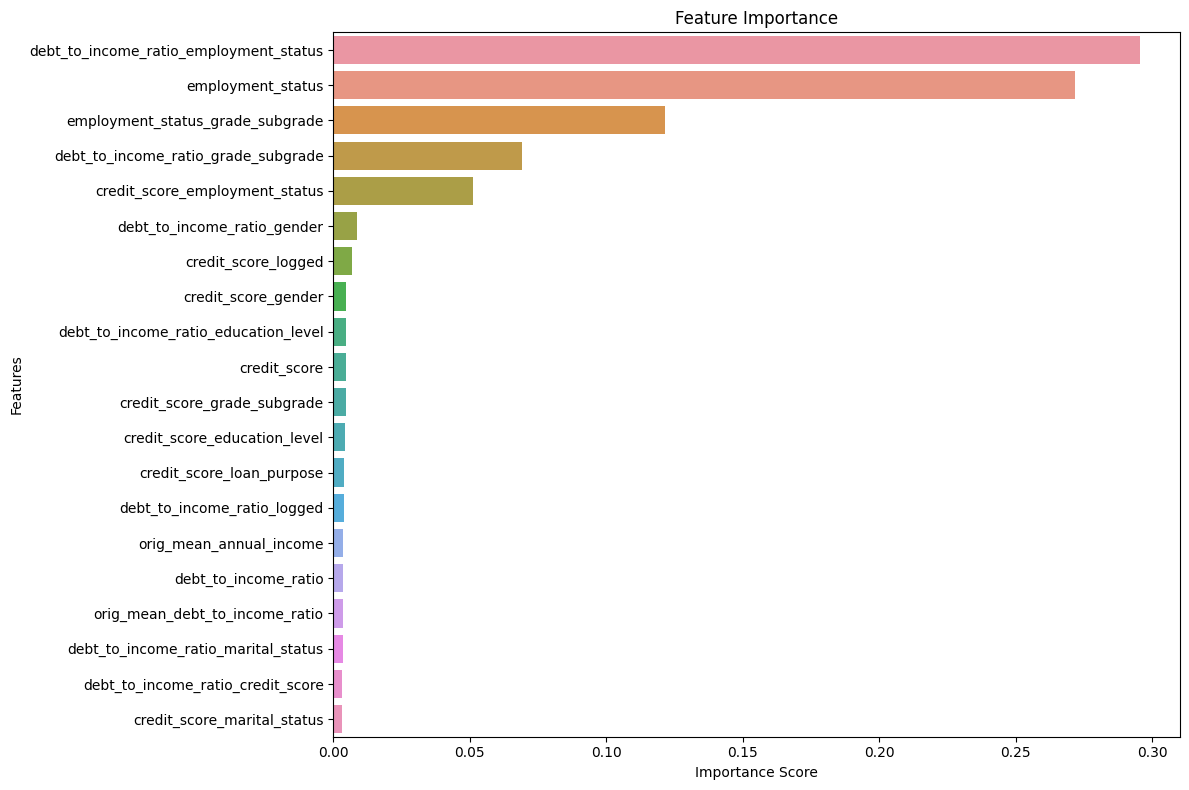

In [36]:
feature_importances = model.feature_importances_
importance_df = pd.DataFrame({
    'feature': FEATURES, 
    'importance': feature_importances
})

importance_df = importance_df.sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=importance_df.head(20)) 
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [37]:
pd.DataFrame({'id': train.id, target: oof_preds}).to_csv(f'oof_xgb_cv_{overall_auc}.csv', index=False)

In [38]:
# save results
submission['loan_paid_back'] = test_preds1
submission.to_csv('submission_1.csv', index=False) 
submission.head()

,id,loan_paid_back
0,593994,0.943366
1,593995,0.959698
2,593996,0.414252
3,593997,0.872374
4,593998,0.958161


In [39]:

# save final results
submission['loan_paid_back'] = (test_preds1 + test_preds) / 2
submission.to_csv('submission.csv', index=False) 
submission.head()

,id,loan_paid_back
0,593994,0.940158
1,593995,0.960579
2,593996,0.427202
3,593997,0.873614
4,593998,0.955227
